# PDAN8412 – Programming for Data Analytics 2
## Part 1 – Recurrent Neural Networks and LSTM
### Author Prediction from Writing Style

**Student Name:** Ubaid Omarjee  
**Student Number:** ST10315716

This notebook follows the Part 1 requirements: dataset justification, planning, Spark-based EDA and cleaning, feature preparation, LSTM model development, evaluation, parameter experimentation and interpretation.



## 1. Dataset and problem

The selected dataset is the **Blog Authorship Corpus**. The task is to predict the author of a blog post from the writing itself. This is a multiclass text-classification problem.

The dataset contains far more than the required 10,000 records, so a balanced working subset will be created. Ten authors with sufficient observations will be selected and up to 1,000 posts per author will be used.

Dataset:
https://www.kaggle.com/datasets/rtatman/blog-authorship-corpus

## 2. Analysis plan

1. Load and inspect the dataset using Spark.
2. Check missing values, duplicates and author distribution.
3. Select a balanced set of authors.
4. Clean the text.
5. Perform EDA on class balance and text length.
6. Convert the final Spark dataset to Pandas for TensorFlow.
7. Encode author labels and create train/validation/test sets.
8. Vectorise text.
9. Train a Bidirectional LSTM baseline.
10. Evaluate accuracy, precision, recall, F1 and the confusion matrix.
11. Train a second configuration and compare the results.
12. Interpret findings and limitations.

In [1]:
# Install the packages required for Spark and Kaggle dataset access.
# TensorFlow and most plotting/scikit-learn packages are normally available in Colab.

!pip -q install pyspark kagglehub

### Interpretation

The required Python packages were installed so that the notebook could perform the Spark-based data analysis and download the selected dataset. PySpark is required because Spark is specifically required for the analysis, while KaggleHub is used to obtain the selected dataset programmatically.

In [2]:
# Import libraries.

import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

# Set random seeds so that results are as reproducible as possible.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


### Interpretation

The libraries imported in this section provide the tools required for the complete analysis. PySpark is used for large-scale data loading, cleaning, aggregation and exploratory analysis. Pandas is used after the Spark-based preparation when the final dataset is small enough to work with locally. Scikit-learn provides data splitting, label encoding and model evaluation metrics, while TensorFlow/Keras is used to build and train the LSTM neural network.

A random seed of 42 was also applied to the Python, NumPy and TensorFlow components. This improves reproducibility by reducing differences caused by random operations during the analysis.

## 3. Start Spark

Spark is used for the required analysis, including loading, aggregation, cleaning, balancing and EDA. The assessment does not require the neural network itself to be trained with Spark.

In [3]:
# Create a local Spark session using the available Colab CPU cores.

spark = (
    SparkSession.builder
    .appName("PDAN8412_Part1_Author_Attribution")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Spark version: 4.0.4


### Interpretation

A local Spark session was created so that Spark could be used throughout the data preparation and exploratory analysis. The `local[*]` setting allows Spark to use the available CPU resources in the Colab environment. The number of shuffle partitions was set to eight to provide a manageable configuration for the local analysis.

Spark version 4.0.4 was successfully started, confirming that the Spark environment was available for the required analysis.

## 4. Download the dataset

In [4]:
# Download the public Blog Authorship Corpus from Kaggle.

import kagglehub

dataset_path = kagglehub.dataset_download(
    "rtatman/blog-authorship-corpus"
)

print("Downloaded dataset directory:")
print(dataset_path)

100%|██████████| 290M/290M [00:02<00:00, 112MB/s]

Extracting files...


Downloaded dataset directory:
/root/.cache/kagglehub/datasets/rtatman/blog-authorship-corpus/versions/2


### Interpretation

The Blog Authorship Corpus was downloaded from Kaggle. This dataset is suitable for the problem because it contains written blog posts together with author identifiers. The text can therefore be used as the input to a text-classification model, while the author identifier provides the target class.

The dataset is substantially larger than the minimum 10,000-record requirement, providing enough observations to select a manageable subset for modelling.

In [5]:
# Find CSV files inside the downloaded directory.
# This prevents the notebook from depending on one hard-coded folder path.

csv_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")
for path in csv_files:
    print(path)

if not csv_files:
    raise FileNotFoundError(
        "No CSV file was found. Check the Kaggle download."
    )

blog_files = [
    p for p in csv_files
    if "blogtext" in os.path.basename(p).lower()
]

DATA_FILE = blog_files[0] if blog_files else csv_files[0]

print("\nSelected file:")
print(DATA_FILE)

CSV files found:
/root/.cache/kagglehub/datasets/rtatman/blog-authorship-corpus/versions/2/blogtext.csv

Selected file:
/root/.cache/kagglehub/datasets/rtatman/blog-authorship-corpus/versions/2/blogtext.csv


### Interpretation

The downloaded dataset was searched for CSV files rather than relying on a hard-coded file path. The `blogtext.csv` file was identified as the relevant dataset file and selected for the analysis.

This approach makes the notebook more robust because it checks the downloaded directory before attempting to load the data.

## 5. Load the data with Spark

In [6]:
# Load the CSV using Spark.
# multiLine=True helps when text fields contain line breaks.

df_spark = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("multiLine", True)
    .option("quote", '"')
    .option("escape", '"')
    .csv(DATA_FILE)
)

print("Columns:")
print(df_spark.columns)

print("\nSchema:")
df_spark.printSchema()

print("\nSample:")
df_spark.show(5, truncate=100)

Columns:
['id', 'gender', 'age', 'topic', 'sign', 'date', 'text']

Schema:
root
 |-- id: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- topic: string (nullable = true)
 |-- sign: string (nullable = true)
 |-- date: string (nullable = true)
 |-- text: string (nullable = true)


Sample:
+-------+------+---+-----------------+--------+------------+----------------------------------------------------------------------------------------------------+
|     id|gender|age|            topic|    sign|        date|                                                                                                text|
+-------+------+---+-----------------+--------+------------+----------------------------------------------------------------------------------------------------+
|2059027|  male| 15|          Student|     Leo| 14,May,2004|           Info has been found (+/- 100 pages, and 4.5 MB of .pdf files) Now i have to wait until...|
|2059027

### Interpretation

The dataset was successfully loaded into a Spark DataFrame. The dataset contains an author identifier (`id`) and a text field (`text`), which are the two most important variables for this analysis.

The remaining variables provide additional information about the blog entries, but the modelling task focuses on using the written text to predict the author. The Spark schema confirms that the author identifier is numerical and the text field is stored as a string.

A sample of five records was also displayed to confirm that the data had been read correctly and that the text content was available for further processing.

In [7]:
# Record count and unique-author count.

original_count = df_spark.count()

print("Original records:", original_count)

if "id" not in df_spark.columns or "text" not in df_spark.columns:
    raise ValueError(
        "Expected columns 'id' and 'text' were not found. Check the dataset file."
    )

AUTHOR_COL = "id"
TEXT_COL = "text"

unique_authors = (
    df_spark
    .select(AUTHOR_COL)
    .where(F.col(AUTHOR_COL).isNotNull())
    .distinct()
    .count()
)

print("Unique authors:", unique_authors)

Original records: 681284
Unique authors: 19320


### Interpretation

The original dataset contains 681,284 records and 19,320 unique author identifiers. This is substantially larger than the minimum dataset requirement and demonstrates that the source contains sufficient data for a multiclass authorship-classification problem.

Because using the complete dataset would be computationally expensive for an individual Colab environment, a smaller working dataset was created. Ten authors with sufficient observations were selected for the modelling task.

## 6. Initial data-quality assessment

In [8]:
# Count null values in the author and text columns.

df_spark.select(
    F.sum(F.col(AUTHOR_COL).isNull().cast("int")).alias("null_authors"),
    F.sum(F.col(TEXT_COL).isNull().cast("int")).alias("null_text")
).show()

# Count null/empty text records.
empty_text_count = (
    df_spark
    .filter(
        F.col(TEXT_COL).isNull() |
        (F.trim(F.col(TEXT_COL)) == "")
    )
    .count()
)

print("Null/empty text records:", empty_text_count)

# Count exact duplicate rows.
duplicate_count = df_spark.count() - df_spark.dropDuplicates().count()
print("Exact duplicate rows:", duplicate_count)

+------------+---------+
|null_authors|null_text|
+------------+---------+
|           0|        0|
+------------+---------+

Null/empty text records: 3085
Exact duplicate rows: 4686


### Interpretation

The initial data-quality assessment showed that there were no null values in the author or text columns. However, 3,085 records contained null or empty text according to the additional text-content check. These records would not provide useful information for an authorship model because there is insufficient textual evidence from which to learn writing patterns.

The dataset also contained 4,686 exact duplicate rows. Duplicate observations can cause repeated examples to influence the analysis disproportionately, so duplicate handling was included as part of the cleaning process.

These results demonstrate that data cleaning was necessary before model development.

## 7. Author distribution

The number of posts per author is examined because class imbalance can cause a classifier to receive much more training information from some authors than others.

In [9]:
# Count posts per author using Spark groupBy.

author_counts = (
    df_spark
    .filter(F.col(AUTHOR_COL).isNotNull())
    .groupBy(AUTHOR_COL)
    .count()
    .orderBy(F.desc("count"))
)

author_counts.show(20, truncate=False)

+-------+-----+
|id     |count|
+-------+-----+
|449628 |4221 |
|734562 |2301 |
|589736 |2294 |
|1975546|2261 |
|958176 |2244 |
|1107146|2237 |
|303162 |2114 |
|942828 |2068 |
|1270648|1951 |
|1784456|1843 |
|955372 |1771 |
|1078410|1731 |
|1325355|1702 |
|883178 |1616 |
|595404 |1561 |
|988941 |1542 |
|1093457|1533 |
|1093691|1533 |
|605396 |1505 |
|322624 |1351 |
+-------+-----+
only showing top 20 rows


### Interpretation

The author distribution is highly uneven in the original dataset. Some authors have several thousand posts while many other authors have substantially fewer observations.

This imbalance is important because a classification model trained directly on the original distribution could receive considerably more training examples from some authors than others. The model could therefore become biased towards authors with larger numbers of posts.

To reduce this issue, ten authors with sufficient observations were selected and an equal number of posts was initially retained for each selected author.

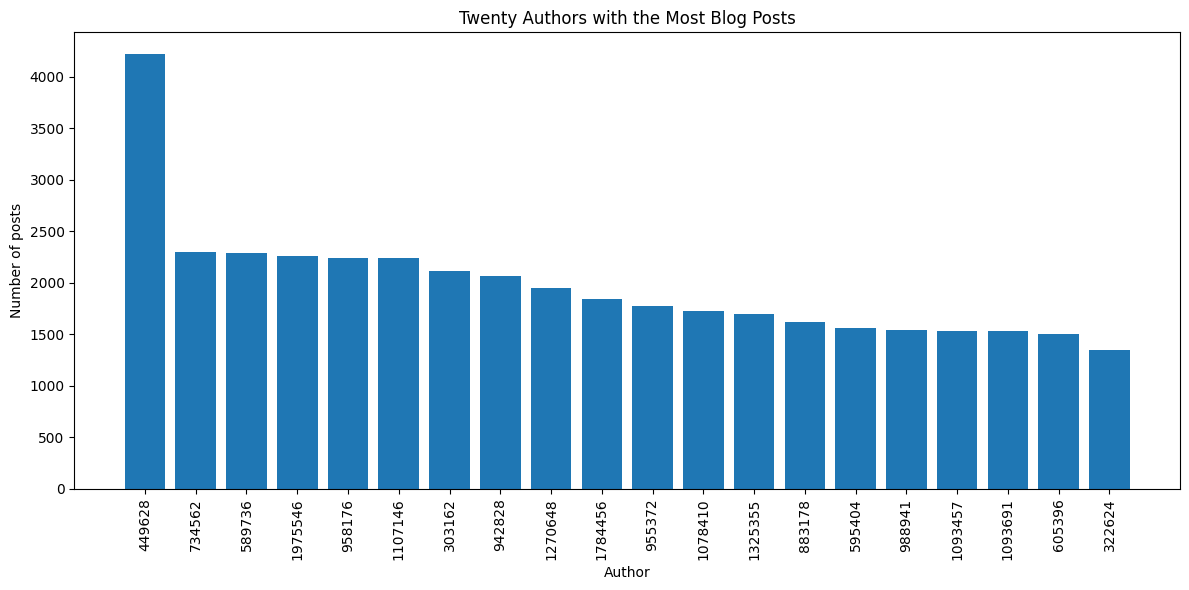

In [10]:
# Plot the 20 authors with the most posts.

top20 = author_counts.limit(20).toPandas()

plt.figure(figsize=(12, 6))
plt.bar(top20[AUTHOR_COL].astype(str), top20["count"])
plt.xticks(rotation=90)
plt.xlabel("Author")
plt.ylabel("Number of posts")
plt.title("Twenty Authors with the Most Blog Posts")
plt.tight_layout()
plt.show()

### Interpretation

The graph confirms the imbalance observed in the Spark aggregation. The number of available posts varies considerably between authors.

Selecting authors with sufficient observations makes it possible to construct a balanced initial dataset. This provides a more controlled environment for evaluating whether the LSTM can distinguish between writing patterns rather than simply benefiting from classes with substantially more observations.

## 8. Create a balanced 10,000-record working dataset

The assessment requires at least 10,000 records. Ten authors are selected and up to 1,000 posts per author are retained. This creates a manageable multiclass problem while maintaining equal class sizes before subsequent cleaning.

In [11]:
NUM_AUTHORS = 10
POSTS_PER_AUTHOR = 1000

# Select the ten authors with the most observations.
selected_authors = (
    author_counts
    .limit(NUM_AUTHORS)
    .select(AUTHOR_COL)
)

selected_authors.show()

# Keep only posts belonging to those authors.
df_selected = (
    df_spark
    .join(selected_authors, on=AUTHOR_COL, how="inner")
    .filter(F.col(TEXT_COL).isNotNull())
    .filter(F.trim(F.col(TEXT_COL)) != "")
)

print("Records after author selection:", df_selected.count())

+-------+
|     id|
+-------+
| 449628|
| 734562|
| 589736|
|1975546|
| 958176|
|1107146|
| 303162|
| 942828|
|1270648|
|1784456|
+-------+

Records after author selection: 23504


### Interpretation

The ten authors with the highest numbers of observations were selected because each had enough posts to contribute up to 1,000 observations. After restricting the dataset to these authors and excluding null or empty text, 23,504 records remained.

The selected authors provide sufficient observations to construct a balanced 10,000-record working dataset while keeping the computational requirements manageable for the Colab environment.

In [12]:
# Create a deterministic hash for each author-text pair.
# This gives a repeatable ordering within each author.

df_selected = df_selected.withColumn(
    "_selection_hash",
    F.sha2(
        F.concat_ws(
            "||",
            F.col(AUTHOR_COL).cast("string"),
            F.col(TEXT_COL)
        ),
        256
    )
)

# Select up to 1,000 posts per author.
author_window = Window.partitionBy(AUTHOR_COL).orderBy("_selection_hash")

df_balanced = (
    df_selected
    .withColumn("_row_number", F.row_number().over(author_window))
    .filter(F.col("_row_number") <= POSTS_PER_AUTHOR)
    .drop("_row_number", "_selection_hash")
)

print("Balanced dataset size:", df_balanced.count())

print("Posts per selected author:")
df_balanced.groupBy(AUTHOR_COL).count().orderBy(AUTHOR_COL).show()

Balanced dataset size: 10000
Posts per selected author:
+-------+-----+
|     id|count|
+-------+-----+
| 303162| 1000|
| 449628| 1000|
| 589736| 1000|
| 734562| 1000|
| 942828| 1000|
| 958176| 1000|
|1107146| 1000|
|1270648| 1000|
|1784456| 1000|
|1975546| 1000|
+-------+-----+



### Interpretation

A deterministic hash was used to create a repeatable ordering of posts within each author. The first 1,000 observations for each selected author were then retained.

The resulting dataset contains exactly 10,000 records, with 1,000 posts for each of the ten authors. This creates an initially balanced multiclass dataset, meaning that every author contributes the same number of observations before the remaining cleaning steps are applied.

Using a deterministic selection process also means that the same records can be selected again when the notebook is rerun with the same data and configuration.

## 9. Clean the text

Cleaning is deliberately moderate. Because this is authorship attribution, removing every punctuation mark or stylistic feature could remove useful information about writing style.

In [13]:
# Remove URLs, convert text to lowercase and normalise whitespace.

df_clean = (
    df_balanced
    .withColumn(
        "clean_text",
        F.regexp_replace(
            F.col(TEXT_COL),
            r"http\S+|www\.\S+",
            " "
        )
    )
    .withColumn(
        "clean_text",
        F.lower(F.col("clean_text"))
    )
    .withColumn(
        "clean_text",
        F.regexp_replace(
            F.col("clean_text"),
            r"\s+",
            " "
        )
    )
    .withColumn(
        "clean_text",
        F.trim(F.col("clean_text"))
    )
    .withColumn(
        "text_length",
        F.length(F.col("clean_text"))
    )
)

# Remove very short posts because they provide limited writing-style evidence.
MIN_TEXT_LENGTH = 50

before_short = df_clean.count()

df_clean = df_clean.filter(
    F.col("text_length") >= MIN_TEXT_LENGTH
)

after_short = df_clean.count()

print("Before short-text filter:", before_short)
print("After short-text filter:", after_short)
print("Short records removed:", before_short - after_short)

# Remove duplicate author-text combinations.
before_duplicates = df_clean.count()

df_clean = df_clean.dropDuplicates(
    [AUTHOR_COL, "clean_text"]
)

after_duplicates = df_clean.count()

print("Before duplicate removal:", before_duplicates)
print("After duplicate removal:", after_duplicates)
print("Duplicate author-text records removed:",
      before_duplicates - after_duplicates)

Before short-text filter: 10000
After short-text filter: 8548
Short records removed: 1452
Before duplicate removal: 8548
After duplicate removal: 8524
Duplicate author-text records removed: 24


### Interpretation

The text was cleaned using relatively moderate preprocessing because this is an authorship-attribution task. URLs were removed because they are not necessarily representative of an author's writing style, while converting text to lowercase and normalising whitespace provides a more consistent representation of the textual input.

Punctuation and other stylistic information were not aggressively removed because these features may contain useful information about how different authors write.

A text-length variable was also created so that the distribution of post lengths could be examined during EDA.

In [14]:
# Final cleaned dataset size and author count.

final_clean_count = df_clean.count()
final_author_count = df_clean.select(AUTHOR_COL).distinct().count()

print("Final cleaned records:", final_clean_count)
print("Final authors:", final_author_count)

Final cleaned records: 8524
Final authors: 10


### Interpretation

The final cleaned dataset contains 8,524 usable blog posts from the ten selected authors. All ten author classes are still represented after cleaning, so no author was completely removed from the analysis.

The dataset is therefore suitable for continuing to the exploratory analysis and machine-learning preparation stages.

## 10. EDA – text length

+-------+-----------------+
|summary|      text_length|
+-------+-----------------+
|  count|             8524|
|   mean|581.1813702487095|
| stddev|1048.222082123272|
|    min|               50|
|    max|            30549|
+-------+-----------------+



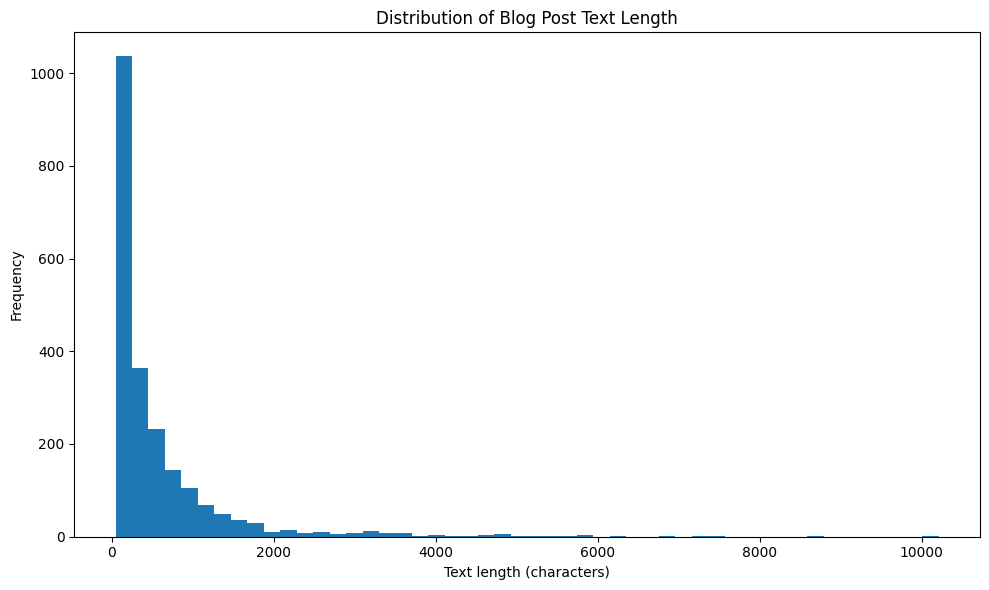

In [15]:
# Summary statistics for text length.

df_clean.select("text_length").describe().show()

# Use a sample for plotting so the full Spark DataFrame does not need
# to be converted to Pandas.

length_pd = (
    df_clean
    .select("text_length")
    .sample(False, 0.25, seed=SEED)
    .toPandas()
)

plt.figure(figsize=(10, 6))
plt.hist(length_pd["text_length"], bins=50)
plt.xlabel("Text length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Blog Post Text Length")
plt.tight_layout()
plt.show()

### Interpretation of text length

The final cleaned dataset contained 8,524 usable blog posts. The average text length was approximately 581 characters, while the standard deviation was approximately 1,048 characters. This relatively large standard deviation indicates substantial variation in the length of individual posts.

The shortest retained post contained 50 characters, which corresponds to the minimum threshold applied during cleaning. The longest post contained 30,549 characters.

The wide variation in text length supports the use of a fixed sequence length during neural-network preparation. A sequence length of 300 tokens was selected so that the model receives a consistent input size while limiting computational requirements. Longer texts may be truncated, which is recognised as a limitation of the analysis.

+-------+-----+
|     id|count|
+-------+-----+
| 303162|  901|
| 449628|  951|
| 589736|  740|
| 734562|  767|
| 942828|  977|
| 958176|  856|
|1107146|  842|
|1270648|  855|
|1784456|  902|
|1975546|  733|
+-------+-----+



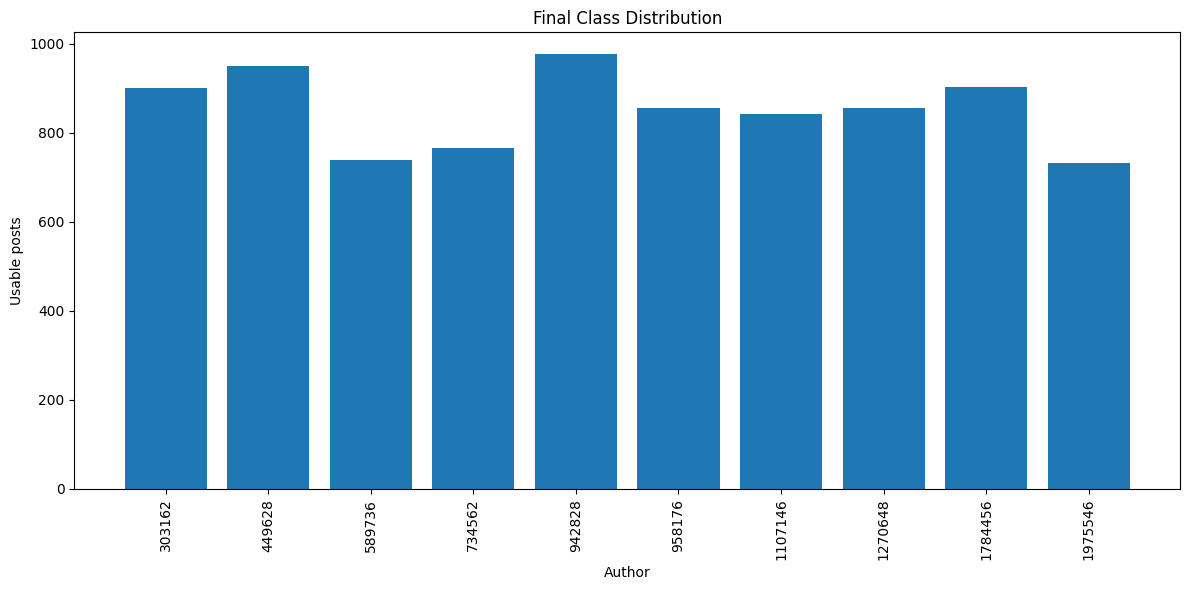

In [16]:
# Check the final class balance after cleaning.

final_author_counts = (
    df_clean
    .groupBy(AUTHOR_COL)
    .count()
    .orderBy(AUTHOR_COL)
)

final_author_counts.show()

final_author_pd = final_author_counts.toPandas()

plt.figure(figsize=(12, 6))
plt.bar(
    final_author_pd[AUTHOR_COL].astype(str),
    final_author_pd["count"]
)
plt.xticks(rotation=90)
plt.xlabel("Author")
plt.ylabel("Usable posts")
plt.title("Final Class Distribution")
plt.tight_layout()
plt.show()

### Interpretation

The cleaning process affected the authors differently, so the final dataset is no longer perfectly balanced. The number of usable posts ranges from 733 for author 1975546 to 977 for author 942828.

Although the original working dataset contained exactly 1,000 posts per author, short-text filtering and duplicate removal resulted in different numbers of usable observations per class.

This difference was considered during model evaluation. Stratified splitting was used later to preserve the relative class distribution across the training, validation and test datasets.

In [17]:
# Inspect a few cleaned examples to confirm that meaningful text remains.

sample_rows = (
    df_clean
    .select(AUTHOR_COL, "clean_text")
    .orderBy(F.rand(SEED))
    .limit(5)
    .toPandas()
)

for i, row in sample_rows.iterrows():
    print(f"--- Example {i+1} ---")
    print("Author:", row[AUTHOR_COL])
    print("Text:", row["clean_text"][:800])
    print()

--- Example 1 ---
Author: 1270648
Text: hello this is andrei again, but since it's vlad's birthday, there is someone else who would like to post something... welcome, annie! hello everyone! happy birthday to vlad :). andrei is here in new york and i think i'm going to keep him here for a while...sorry guys. andrei is now kicking me off my computer :(. i hope i will get to see some of you in august. byebye. annie

--- Example 2 ---
Author: 449628
Text: 'god laughs because he knows more than we do. god has sharper vision.' -- miriam pollard

--- Example 3 ---
Author: 1270648
Text: i got it, but who needs total control? what i'm persuaded in is that we all do equally stupid things sometimes. it's a quite dull subject to argue about anyway. the thing i can't figure out is why is it more fashionable to keep all your stuff inside, not to let anybody know what's on your mind? why is it cool to be cold and insensitive? i have been like this for the most of my sensible lifetime, and it proved t

### Interpretation

Several cleaned examples were displayed to verify that the preprocessing retained meaningful natural-language content. The examples show that the text remains readable and contains substantial linguistic information after URL removal, lowercasing and whitespace normalisation.

This check is important because overly aggressive preprocessing could remove information that is useful for identifying writing style. The examples indicate that the cleaning process retained meaningful textual content for the LSTM model.

## 11. Convert the final Spark dataset to Pandas

Spark has now been used for loading, cleaning, aggregation, balancing and EDA. The final working dataset is small enough to move to Pandas for TensorFlow/Keras modelling.

In [18]:
# Keep only the columns required for modelling.

df = (
    df_clean
    .select(AUTHOR_COL, "clean_text")
    .toPandas()
)

print("Final modelling DataFrame shape:", df.shape)
df.head()

Final modelling DataFrame shape: (8524, 2)


,id,clean_text
0,734562,"umm, as a new yorker, i must make an alternate..."
1,734562,"you are already my soul sister, angie. saw tor..."
2,734562,"angie came out of surgery fine, and asked me t..."
3,734562,"yay!!!!!! my white magic works again! now, bac..."
4,734562,"keep up with the news, bunny toes. he announce..."


### Interpretation

After Spark had completed the required large-scale data preparation, only the author identifier and cleaned text were retained for modelling.

The resulting DataFrame contains 8,524 observations and two modelling columns. At this stage the dataset is sufficiently small to move from Spark to Pandas and TensorFlow without needing Spark to train the neural network.

This also maintains a clear separation between the required Spark analysis and the TensorFlow modelling process.

## 12. Encode the author labels

In [19]:
# Convert author IDs into numerical classes.

label_encoder = LabelEncoder()

df["author_label"] = label_encoder.fit_transform(
    df[AUTHOR_COL]
)

NUM_CLASSES = len(label_encoder.classes_)

print("Number of classes:", NUM_CLASSES)

for number, author in enumerate(label_encoder.classes_):
    print(number, "->", author)

Number of classes: 10
0 -> 303162
1 -> 449628
2 -> 589736
3 -> 734562
4 -> 942828
5 -> 958176
6 -> 1107146
7 -> 1270648
8 -> 1784456
9 -> 1975546


### Interpretation

The author IDs are identifiers rather than numerical measurements, so they were converted into numerical class labels using `LabelEncoder`.

Ten unique author classes were identified. Each original author ID was mapped to a unique integer between 0 and 9. This representation allows the neural network to use the author as a multiclass classification target while preserving the original author identities for later interpretation.

## 13. Train/validation/test split

The data is split into training, validation and test sets. Stratification preserves the class distribution in each split.

In [20]:
# First create an 80% training set and 20% temporary set.
X_train, X_temp, y_train, y_temp = train_test_split(
    df["clean_text"].values,
    df["author_label"].values,
    test_size=0.20,
    random_state=SEED,
    stratify=df["author_label"].values
)

# Split the temporary set equally into validation and test data.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))

Training: 6819
Validation: 852
Testing: 853


### Interpretation

The cleaned dataset was divided into three subsets. Approximately 80% of the observations were allocated to training, while the remaining 20% was divided equally between validation and test data.

This produced 6,819 training observations, 852 validation observations and 853 test observations.

Stratification was applied during both splits so that the relative representation of the ten author classes was preserved. The test set was kept separate from model training and was only used for final evaluation of performance on unseen data.

## 14. Text vectorisation

TextVectorisation converts raw text into integer token sequences. The vocabulary is learned from training text only to reduce data leakage.

In [21]:
# Neural-network parameters.

VOCAB_SIZE = 20000
SEQUENCE_LENGTH = 300
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.50
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 15

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

# Learn vocabulary from training data only.
vectorizer.adapt(
    tf.data.Dataset
    .from_tensor_slices(X_train)
    .batch(BATCH_SIZE)
)

print("Vocabulary size learned:", len(vectorizer.get_vocabulary()))

Vocabulary size learned: 20000


### Interpretation

The text was converted from raw strings into numerical token sequences using TensorFlow's `TextVectorization` layer.

A maximum vocabulary of 20,000 tokens was selected to provide sufficient representation of the language while limiting computational requirements. Each document was converted to a fixed sequence length of 300 tokens so that all inputs have the same shape.

Importantly, the vectoriser was adapted using the training data only. This prevents information from the validation and test sets from influencing the learned vocabulary and reduces the risk of data leakage.

The vocabulary reached the configured maximum of 20,000 tokens.

In [22]:
# Build batched TensorFlow datasets.

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices((X_train, y_train))
    .shuffle(5000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

validation_dataset = (
    tf.data.Dataset
    .from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices((X_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

### Interpretation

The training, validation and test arrays were converted into TensorFlow datasets and divided into batches of 64 observations.

The training data was shuffled to reduce the possibility that the order of observations could influence learning. Validation and test data were not shuffled because their purpose is to provide consistent evaluation datasets.

Prefetching was also enabled to improve the efficiency of data delivery during model training.

## 15. Baseline Bidirectional LSTM

Architecture:

**TextVectorization → Embedding → Bidirectional LSTM → Dense → Dropout → Softmax**

The softmax layer contains one output probability for each author class.

In [23]:
# Build the baseline model.

baseline_model = tf.keras.Sequential([
    vectorizer,

    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(LSTM_UNITS)
    ),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dropout(
        DROPOUT_RATE
    ),

    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Interpretation

The baseline model uses a sequence of layers designed for text classification.

First, `TextVectorization` converts the input text into integer token sequences. The Embedding layer then converts these integer tokens into dense numerical representations.

A Bidirectional LSTM is used to process the sequence from both directions, allowing the model to learn patterns from information appearing before and after a particular word within the sequence.

A dense ReLU layer provides additional nonlinear processing, while dropout is used to reduce overfitting. The final softmax layer contains ten outputs, corresponding to the ten possible authors.

The model uses the Adam optimiser with a learning rate of 0.001 and sparse categorical cross-entropy because this is a multiclass classification problem with integer class labels.

In [24]:
# Early stopping prevents unnecessary training when validation loss
# stops improving. The best weights are restored.

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 101s 876ms/step - accuracy: 0.2169 - loss: 2.1204 - val_accuracy: 0.3615 - val_loss: 1.8081
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 95s 888ms/step - accuracy: 0.4392 - loss: 1.4823 - val_accuracy: 0.5270 - val_loss: 1.2538
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 91s 852ms/step - accuracy: 0.6046 - loss: 0.9539 - val_accuracy: 0.5552 - val_loss: 1.0465
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 92s 865ms/step - accuracy: 0.6935 - loss: 0.6657 - val_accuracy: 0.5622 - val_loss: 1.0359
Epoch 5/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 140s 846ms/step - accuracy: 0.7038 - loss: 0.5618 - val_accuracy: 0.5751 - val_loss: 1.0364
Epoch 6/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.7281 - loss: 0.5040 - val_accuracy: 0.5493 - val_loss: 1.1449
Epoch 7/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 101s 942ms/step - accuracy: 0.7387 - loss: 0.4699 - val_accuracy: 0.5446 - val_loss: 1.1885


### Interpretation

The baseline model improved substantially during the first several training epochs. Training accuracy increased from approximately 21.69% in the first epoch to approximately 73.87% by epoch 7.

Validation accuracy also improved initially, increasing from approximately 36.15% to a maximum of approximately 57.51%. However, after reaching its highest validation accuracy, validation performance began to decline while training accuracy continued to increase.

Validation loss also stopped improving and began increasing. This difference between training and validation performance suggests that the model was beginning to overfit the training data.

Early stopping was therefore useful because it prevents unnecessary additional training after validation performance stops improving.

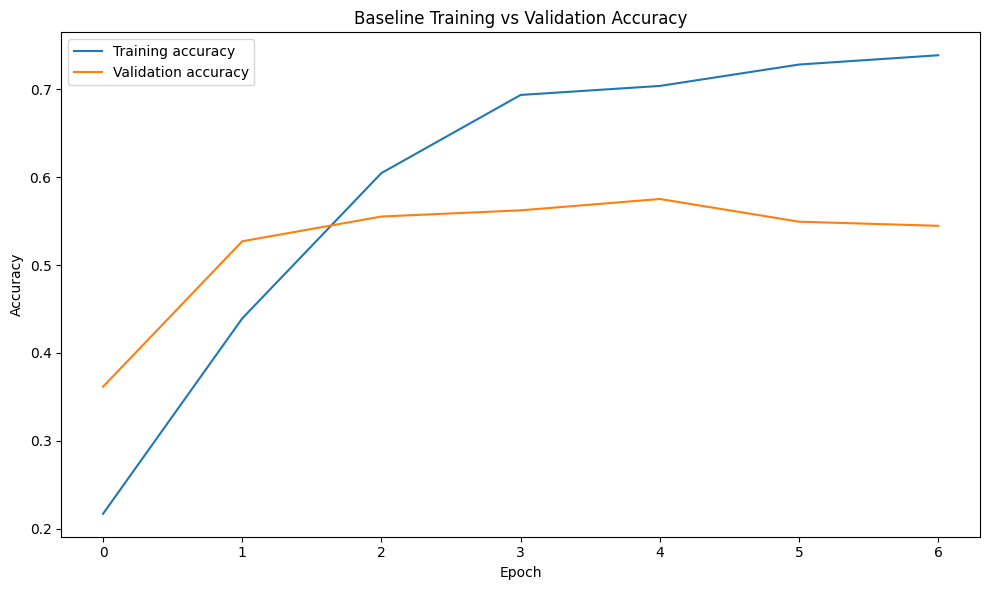

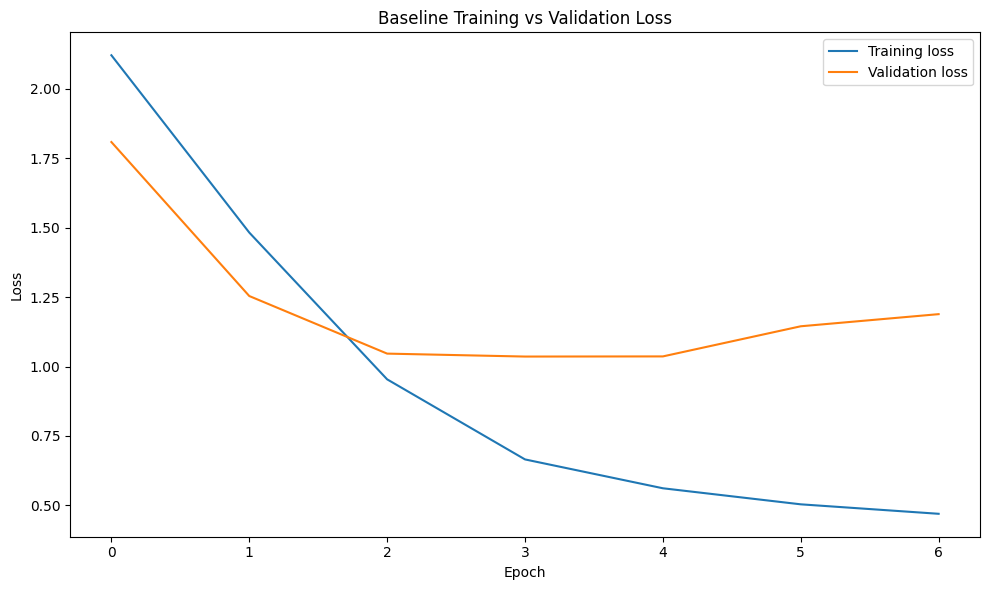

In [25]:
# Plot baseline training and validation accuracy.

plt.figure(figsize=(10, 6))
plt.plot(
    baseline_history.history["accuracy"],
    label="Training accuracy"
)
plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Plot baseline training and validation loss.

plt.figure(figsize=(10, 6))
plt.plot(
    baseline_history.history["loss"],
    label="Training loss"
)
plt.plot(
    baseline_history.history["val_loss"],
    label="Validation loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

The accuracy graph shows that training performance continued to improve while validation performance reached a peak and then declined. This indicates that the model was becoming increasingly specialised to the training observations.

The loss graph provides additional evidence of this behaviour. Training loss decreased as the model learned the training examples, while validation loss stopped decreasing and subsequently increased.

The difference between the two curves indicates that additional training would not necessarily improve generalisation to unseen blog posts. This supports the use of early stopping and the restoration of the best validation-loss weights.

## 16. Evaluate the baseline model

Accuracy, precision, recall and F1-score are reported. The confusion matrix is used to identify which authors are being confused.

In [26]:
# Evaluate the model on the unseen test data.

baseline_loss, baseline_accuracy = baseline_model.evaluate(
    test_dataset,
    verbose=0
)

baseline_probabilities = baseline_model.predict(
    test_dataset,
    verbose=0
)

baseline_predictions = np.argmax(
    baseline_probabilities,
    axis=1
)

# Recover true labels.
y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_dataset
])

baseline_precision = precision_score(
    y_true, baseline_predictions,
    average="weighted", zero_division=0
)

baseline_recall = recall_score(
    y_true, baseline_predictions,
    average="weighted", zero_division=0
)

baseline_f1 = f1_score(
    y_true, baseline_predictions,
    average="weighted", zero_division=0
)

print("Baseline test loss:", baseline_loss)
print("Baseline accuracy:", baseline_accuracy)
print("Baseline precision:", baseline_precision)
print("Baseline recall:", baseline_recall)
print("Baseline F1:", baseline_f1)

Baseline test loss: 1.079632043838501
Baseline accuracy: 0.5486518144607544
Baseline precision: 0.5392595823537639
Baseline recall: 0.5486518171160609
Baseline F1: 0.5241518137108072


### Interpretation

The baseline model was evaluated using the unseen test dataset. The model achieved a test accuracy of approximately 54.87%.

The weighted precision was approximately 53.93%, while weighted recall was approximately 54.87%. The weighted F1-score was approximately 52.42%.

The results show that the model was able to identify author-related patterns from the text, but performance was not uniform across all classes. Because accuracy alone does not show how performance differs between individual authors, the classification report and confusion matrix were also examined.

In [28]:
# Detailed per-author performance.
# The labels argument explicitly tells sklearn to include every author class.
# Converting the author names to strings also prevents formatting issues.

all_labels = np.arange(NUM_CLASSES)

print(
    classification_report(
        y_true,
        baseline_predictions,
        labels=all_labels,
        target_names=[str(x) for x in label_encoder.classes_],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      303162       0.74      0.59      0.65        90
      449628       0.63      0.69      0.66        95
      589736       0.20      0.01      0.03        74
      734562       0.22      0.11      0.14        76
      942828       0.95      0.83      0.89        98
      958176       0.31      0.23      0.27        86
     1107146       0.35      0.54      0.42        84
     1270648       0.64      0.79      0.71        86
     1784456       0.82      0.82      0.82        91
     1975546       0.32      0.70      0.44        73

    accuracy                           0.55       853
   macro avg       0.52      0.53      0.50       853
weighted avg       0.54      0.55      0.52       853



### Interpretation

The classification report shows substantial differences in performance between the ten authors.

Author 942828 achieved an F1-score of approximately 0.89, while author 1784456 achieved approximately 0.82. Other authors were considerably more difficult to classify. For example, author 589736 achieved an F1-score of approximately 0.03, while author 734562 achieved approximately 0.14.

This variation indicates that some authors have textual patterns that are more distinguishable within the selected dataset than others. It also demonstrates why per-class precision, recall and F1-score are important alongside overall accuracy.

The model therefore cannot be described as performing equally well for every author.

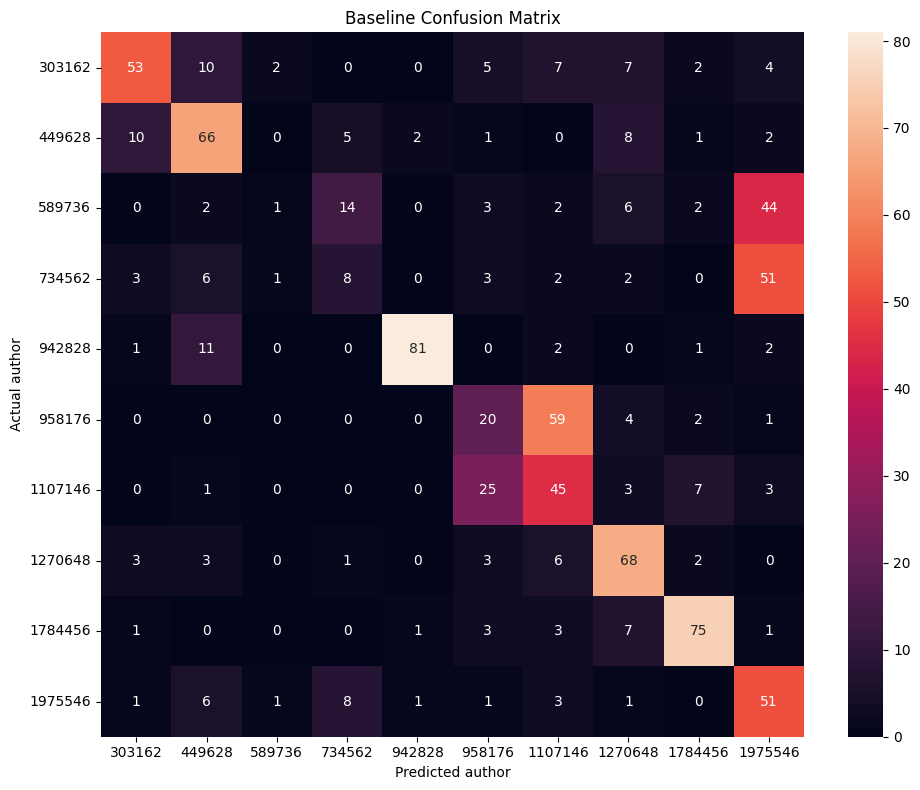

In [29]:
# Baseline confusion matrix.

baseline_cm = confusion_matrix(
    y_true,
    baseline_predictions
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted author")
plt.ylabel("Actual author")
plt.title("Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

### Interpretation

The confusion matrix shows how the model's predictions are distributed across the ten author classes.

Correct predictions appear along the diagonal, while values outside the diagonal represent cases where text from one author was classified as another author.

The presence of errors between several author classes indicates that the model has difficulty distinguishing some writing patterns. This supports the differences observed in the classification report, where some authors have substantially lower recall and F1-scores than others.

The confusion matrix therefore provides more detailed information than overall accuracy alone.

## 17. Hyperparameter experiment

The baseline model was used as the reference configuration. A second model was then trained with a larger LSTM layer, a lower dropout rate and a smaller learning rate.

The purpose of this experiment was to investigate whether increasing the recurrent layer capacity and reducing the learning rate would improve the model's ability to generalise to unseen text.

### Baseline configuration

- LSTM units: 64
- Dropout: 0.50
- Learning rate: 0.001

### Experimental configuration

- LSTM units: 128
- Dropout: 0.40
- Learning rate: 0.0005

The two configurations are compared using test accuracy, precision, recall and weighted F1-score.

In [30]:
# Use a separate vectorizer for the experimental model.

experiment_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

experiment_vectorizer.adapt(
    tf.data.Dataset
    .from_tensor_slices(X_train)
    .batch(BATCH_SIZE)
)

# Build the experimental model.

experiment_model = tf.keras.Sequential([
    experiment_vectorizer,

    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(128)
    ),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.40),

    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

experiment_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

experiment_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Interpretation

The experimental model increases the Bidirectional LSTM size from 64 to 128 units, providing greater recurrent capacity for learning patterns in the text.

The dropout rate was reduced from 0.50 to 0.40, while the Adam learning rate was reduced from 0.001 to 0.0005.

These changes were designed to test whether a larger recurrent representation combined with smaller optimisation steps could improve generalisation compared with the baseline configuration.

In [31]:
# Train the experimental model.

experiment_history = experiment_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.1991 - loss: 2.1646 - val_accuracy: 0.2993 - val_loss: 1.9337
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.3498 - loss: 1.7495 - val_accuracy: 0.4073 - val_loss: 1.5889
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.5243 - loss: 1.2529 - val_accuracy: 0.4953 - val_loss: 1.2771


### Interpretation

The experimental model showed improvement during the initial training epochs. Validation accuracy increased from approximately 29.93% in the first epoch to approximately 49.53% by epoch 3.

However, the important comparison is not the early training performance alone. The experimental model must be evaluated on the unseen test dataset and compared directly with the baseline model using the same evaluation metrics.

This allows the effect of the changed hyperparameters to be assessed using objective performance measures.

In [32]:
# Evaluate the experimental model.

experiment_loss, experiment_accuracy = experiment_model.evaluate(
    test_dataset,
    verbose=0
)

experiment_probabilities = experiment_model.predict(
    test_dataset,
    verbose=0
)

experiment_predictions = np.argmax(
    experiment_probabilities,
    axis=1
)

experiment_precision = precision_score(
    y_true, experiment_predictions,
    average="weighted", zero_division=0
)

experiment_recall = recall_score(
    y_true, experiment_predictions,
    average="weighted", zero_division=0
)

experiment_f1 = f1_score(
    y_true, experiment_predictions,
    average="weighted", zero_division=0
)

print("Experimental accuracy:", experiment_accuracy)
print("Experimental precision:", experiment_precision)
print("Experimental recall:", experiment_recall)
print("Experimental F1:", experiment_f1)

Experimental accuracy: 0.32121923565864563
Experimental precision: 0.18782224705035755
Experimental recall: 0.3212192262602579
Experimental F1: 0.22978901345618116


### Interpretation

The experimental model achieved a test accuracy of approximately 32.12%, weighted precision of approximately 18.78%, weighted recall of approximately 32.12% and weighted F1-score of approximately 22.98%.

These results are substantially lower than the baseline model's test performance. Therefore, the changes to the LSTM size, dropout and learning rate did not improve the model's generalisation on the unseen test data.

The experiment demonstrates that increasing model capacity does not automatically result in better performance. In this case, the original baseline configuration produced stronger test results.

,Model,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1
0,Baseline,0.548652,0.539260,0.548652,0.524152
1,Experiment,0.321219,0.187822,0.321219,0.229789


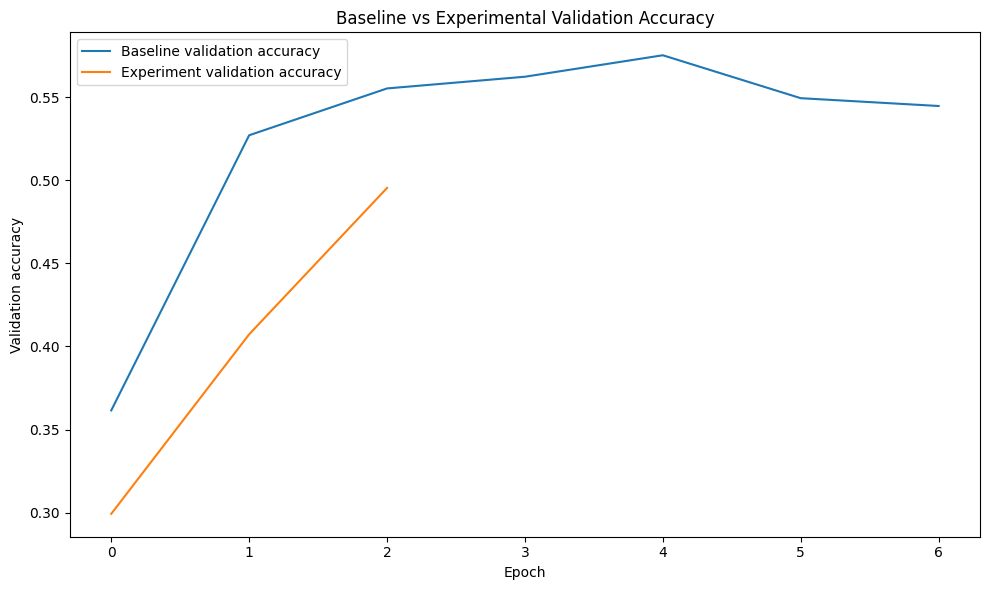

In [33]:
# Compare the baseline and experimental configurations.

comparison = pd.DataFrame({
    "Model": ["Baseline", "Experiment"],
    "Test Accuracy": [baseline_accuracy, experiment_accuracy],
    "Weighted Precision": [baseline_precision, experiment_precision],
    "Weighted Recall": [baseline_recall, experiment_recall],
    "Weighted F1": [baseline_f1, experiment_f1]
})

display(comparison)

plt.figure(figsize=(10, 6))
plt.plot(
    baseline_history.history["val_accuracy"],
    label="Baseline validation accuracy"
)
plt.plot(
    experiment_history.history["val_accuracy"],
    label="Experiment validation accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Baseline vs Experimental Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

The comparison shows that the baseline model achieved higher test performance than the experimental configuration across the reported metrics.

The baseline achieved approximately 54.87% accuracy and a weighted F1-score of approximately 52.42%, compared with approximately 32.12% accuracy and 22.98% weighted F1 for the experimental model.

The validation-accuracy comparison also allows the learning behaviour of the two configurations to be examined across epochs. Based on the test metrics, the experimental hyperparameter changes did not provide an improvement over the baseline.

## 18. Select and evaluate the final model



In [34]:
# Evidence-based final-model selection.

if experiment_f1 >= baseline_f1:
    final_model = experiment_model
    final_predictions = experiment_predictions
    final_model_name = "Experimental model"
else:
    final_model = baseline_model
    final_predictions = baseline_predictions
    final_model_name = "Baseline model"

print("Selected final model:", final_model_name)

final_f1 = f1_score(
    y_true, final_predictions,
    average="weighted", zero_division=0
)

final_accuracy = accuracy_score(
    y_true, final_predictions
)

print("Final accuracy:", final_accuracy)
print("Final weighted F1:", final_f1)

Selected final model: Baseline model
Final accuracy: 0.5486518171160609
Final weighted F1: 0.5241518137108072


### Interpretation

The baseline model was selected as the final model because it achieved the higher weighted F1-score on the unseen test data.

The final model achieved an accuracy of approximately 54.87% and a weighted F1-score of approximately 52.42%. The experimental configuration was not selected because its weighted F1-score was substantially lower.

The selection was therefore based on measured test performance rather than choosing a model according to assumptions about which architecture should perform better.

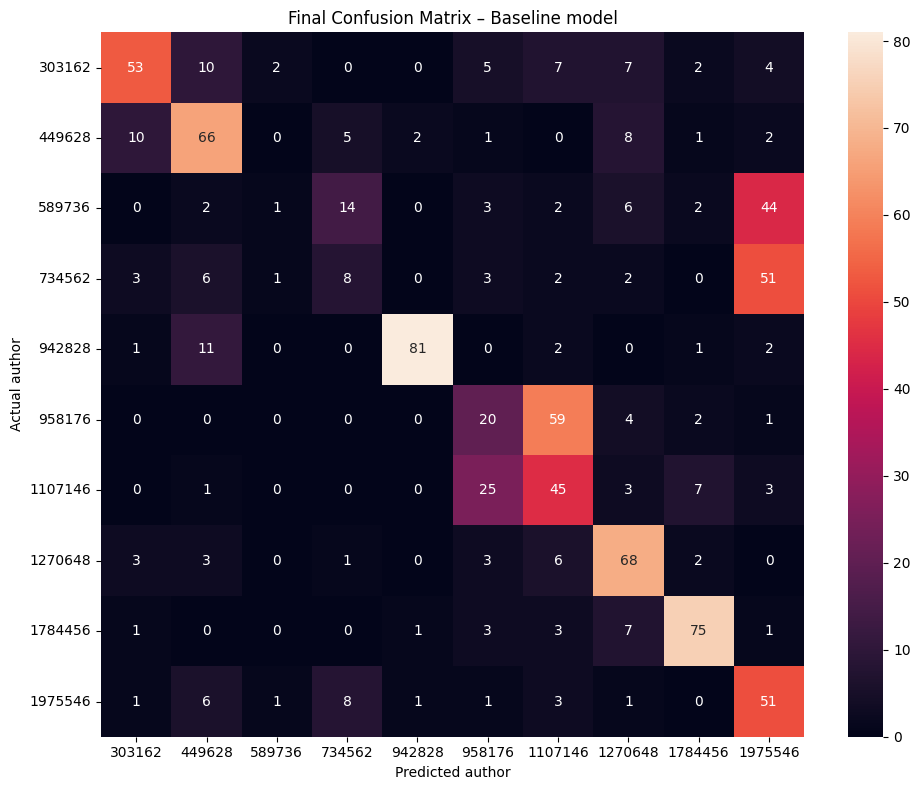

In [35]:
# Final confusion matrix.

final_cm = confusion_matrix(
    y_true,
    final_predictions
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted author")
plt.ylabel("Actual author")
plt.title(f"Final Confusion Matrix – {final_model_name}")
plt.tight_layout()
plt.show()

### Interpretation

The trained final model was tested on an artificial text sample that was not part of the training or test datasets.

The model predicted author 303162 as the most likely author and assigned a probability of approximately 89.44% to that class.

This example demonstrates how the trained model can be used to classify new text. However, the predicted probability should not be interpreted as proof that the text was actually written by that author. The example only demonstrates the model's prediction based on the patterns learned from the selected training data.

## 19. Example prediction

The text below is artificial and is only used to demonstrate how a new text sample would be classified.

In [37]:
# Example of predicting the author of completely new text.
# A TensorFlow string tensor is used instead of a NumPy string array
# to avoid dtype compatibility issues in the current Colab environment.

sample_text = """
I spent the afternoon walking through the city and thinking about
the work that still needed to be completed. The quiet streets gave
me enough time to reflect on the week and plan what I wanted to do next.
"""

# Convert the text directly into a TensorFlow string tensor.
sample_input = tf.constant(
    [sample_text],
    dtype=tf.string
)

# Ask the selected final model to predict the probabilities
# for each author class.
sample_probabilities = final_model.predict(
    sample_input,
    verbose=0
)[0]

# Find the class with the highest predicted probability.
predicted_class = int(
    np.argmax(sample_probabilities)
)

# Convert the numerical class back to the original author ID.
predicted_author = label_encoder.inverse_transform(
    [predicted_class]
)[0]

# Obtain the probability assigned to the predicted author.
confidence = float(
    sample_probabilities[predicted_class]
)

print("Predicted author:", predicted_author)
print("Model probability:", confidence)

Predicted author: 303162
Model probability: 0.8944187164306641


## 20. Limitations and conclusion

### Limitations

The analysis has several limitations. First, the Blog Authorship Corpus represents historical blog writing, so the writing patterns contained in the dataset may not fully represent contemporary writing.

Second, the model was trained using ten selected authors rather than the complete author population. Therefore, the results should be interpreted as classification performance for the selected authors rather than evidence that the model can identify any possible author.

Another limitation is that the model may learn topic- or vocabulary-specific patterns in addition to writing style. Authors who frequently discuss particular subjects may therefore be distinguishable because of their vocabulary rather than purely stylistic characteristics.

The model also uses a fixed sequence length of 300 tokens. Longer posts are therefore truncated, while shorter posts are padded. This may result in some information being excluded from longer texts.

Finally, neural-network results can vary depending on random initialisation and the computational environment. The model should therefore be evaluated on additional data before being used in a real-world authorship-attribution system.

### Conclusion

The analysis developed a Bidirectional LSTM model for predicting the author of a blog post based on textual information. The baseline model achieved a test accuracy of approximately 54.87% and a weighted F1-score of approximately 52.42%.

The experimental configuration did not improve the baseline model. It achieved approximately 32.12% test accuracy and a weighted F1-score of approximately 22.98%. The baseline model was therefore retained as the final model based on its stronger test F1-score.

The results demonstrate that the model was able to identify some author-specific patterns, although performance varied substantially between authors. Further improvements could investigate different sequence lengths, preprocessing approaches, model architectures and larger or more representative author samples.

## 21. References



Useful technical sources:

- TensorFlow – Text classification with an RNN: https://www.tensorflow.org/text/tutorials/text_classification_rnn
- Keras – LSTM layer: https://keras.io/api/layers/recurrent_layers/lstm/
- Apache Spark – DataFrame.groupBy: https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.groupBy.html
- Kaggle – Blog Authorship Corpus: https://www.kaggle.com/datasets/rtatman/blog-authorship-corpus